# load your week 1 cleaned dataset

In [415]:
import pandas as pd
import numpy as np

In [416]:
df=pd.read_csv(r'C:\Users\j\OneDrive\Desktop\5thsem_OJT\project1_diabates\data\processed\project1_diabetes_cleaned.csv',parse_dates=['last_checkup_date'])

In [417]:
df.head(10)

,patient_id,age,gender,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,physical_activity,smoker,last_checkup_date,outcome
0,P00826,79,male,0,124.0,71.0,30.0,124.0,23.4,0.588,Unknown,NO,2023-04-20,0
1,P00108,37,male,0,153.0,85.0,24.0,42.0,33.9,0.192,Medium,YES,2024-05-03,1
2,P00517,39,female,0,142.0,68.0,22.0,159.0,26.9,0.777,Low,UNKNOWN,2023-07-08,0
3,P00687,68,female,7,121.0,88.0,26.0,124.0,29.0,1.217,Unknown,YES,2024-04-14,1
4,P00927,75,female,0,107.0,84.0,31.0,101.0,21.2,0.278,Low,NO,2024-01-27,0
5,P00755,37,female,0,145.0,80.0,26.0,124.0,22.0,0.488,High,YES,2024-01-10,0
6,P00431,58,male,5,95.0,72.0,26.0,170.0,27.2,0.197,High,NO,2023-12-25,0
7,P00542,58,female,3,150.0,68.0,17.0,124.0,46.0,0.808,Medium,NO,2024-06-20,1
8,P00929,32,female,6,129.0,74.0,26.0,226.0,20.6,0.655,High,UNKNOWN,2023-10-15,1
9,P00513,61,female,0,161.0,77.0,35.0,201.0,35.0,1.229,Medium,YES,2023-12-22,1


In [418]:
df.dtypes

patient_id                      str
age                           int64
gender                          str
pregnancies                   int64
glucose                     float64
blood_pressure              float64
skin_thickness              float64
insulin                     float64
bmi                         float64
diabetes_pedigree           float64
physical_activity               str
smoker                          str
last_checkup_date    datetime64[us]
outcome                       int64
dtype: object

In [419]:
df.shape

(950, 14)

# create an age-band feature

In [420]:
df['age_band']= pd.cut(df['age'],bins=[0,35,55,120] ,labels=('Youth','middle-Aged','senior'))

In [421]:
df.head(10)

,patient_id,age,gender,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,physical_activity,smoker,last_checkup_date,outcome,age_band
0,P00826,79,male,0,124.0,71.0,30.0,124.0,23.4,0.588,Unknown,NO,2023-04-20,0,senior
1,P00108,37,male,0,153.0,85.0,24.0,42.0,33.9,0.192,Medium,YES,2024-05-03,1,middle-Aged
2,P00517,39,female,0,142.0,68.0,22.0,159.0,26.9,0.777,Low,UNKNOWN,2023-07-08,0,middle-Aged
3,P00687,68,female,7,121.0,88.0,26.0,124.0,29.0,1.217,Unknown,YES,2024-04-14,1,senior
4,P00927,75,female,0,107.0,84.0,31.0,101.0,21.2,0.278,Low,NO,2024-01-27,0,senior
5,P00755,37,female,0,145.0,80.0,26.0,124.0,22.0,0.488,High,YES,2024-01-10,0,middle-Aged
6,P00431,58,male,5,95.0,72.0,26.0,170.0,27.2,0.197,High,NO,2023-12-25,0,senior
7,P00542,58,female,3,150.0,68.0,17.0,124.0,46.0,0.808,Medium,NO,2024-06-20,1,senior
8,P00929,32,female,6,129.0,74.0,26.0,226.0,20.6,0.655,High,UNKNOWN,2023-10-15,1,Youth
9,P00513,61,female,0,161.0,77.0,35.0,201.0,35.0,1.229,Medium,YES,2023-12-22,1,senior


create a bmi category feature

In [422]:
df['bmi_category']=pd.cut(df['bmi'],bins=[0,18.5,25,30,100],labels=('under_weight','normal','over_weight','obese'))

In [423]:
df.head()

,patient_id,age,gender,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,physical_activity,smoker,last_checkup_date,outcome,age_band,bmi_category
0,P00826,79,male,0,124.0,71.0,30.0,124.0,23.4,0.588,Unknown,NO,2023-04-20,0,senior,normal
1,P00108,37,male,0,153.0,85.0,24.0,42.0,33.9,0.192,Medium,YES,2024-05-03,1,middle-Aged,obese
2,P00517,39,female,0,142.0,68.0,22.0,159.0,26.9,0.777,Low,UNKNOWN,2023-07-08,0,middle-Aged,over_weight
3,P00687,68,female,7,121.0,88.0,26.0,124.0,29.0,1.217,Unknown,YES,2024-04-14,1,senior,over_weight
4,P00927,75,female,0,107.0,84.0,31.0,101.0,21.2,0.278,Low,NO,2024-01-27,0,senior,normal


In [424]:
df['bmi_category'].value_counts()

bmi_category
obese           553
over_weight     235
normal          124
under_weight     38
Name: count, dtype: int64

In [425]:
df['glucose_category']=pd.cut(df['glucose'],bins=[0,100,126,300],labels=('normal','prediabetic','diabetic'))

In [426]:
df.head()

,patient_id,age,gender,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,physical_activity,smoker,last_checkup_date,outcome,age_band,bmi_category,glucose_category
0,P00826,79,male,0,124.0,71.0,30.0,124.0,23.4,0.588,Unknown,NO,2023-04-20,0,senior,normal,prediabetic
1,P00108,37,male,0,153.0,85.0,24.0,42.0,33.9,0.192,Medium,YES,2024-05-03,1,middle-Aged,obese,diabetic
2,P00517,39,female,0,142.0,68.0,22.0,159.0,26.9,0.777,Low,UNKNOWN,2023-07-08,0,middle-Aged,over_weight,diabetic
3,P00687,68,female,7,121.0,88.0,26.0,124.0,29.0,1.217,Unknown,YES,2024-04-14,1,senior,over_weight,prediabetic
4,P00927,75,female,0,107.0,84.0,31.0,101.0,21.2,0.278,Low,NO,2024-01-27,0,senior,normal,prediabetic


In [427]:
df["glucose_category"].value_counts()

glucose_category
diabetic       349
prediabetic    337
normal         264
Name: count, dtype: int64

ashfiqua kunjimolll

In [428]:
df["glucose_category"].value_counts()

glucose_category
diabetic       349
prediabetic    337
normal         264
Name: count, dtype: int64

In [429]:
df['bmi_category']

0           normal
1            obese
2      over_weight
3      over_weight
4           normal
          ...     
945          obese
946          obese
947         normal
948          obese
949    over_weight
Name: bmi_category, Length: 950, dtype: category
Categories (4, str): ['under_weight' < 'normal' < 'over_weight' < 'obese']

create insulin to glucose ratio feature

In [430]:
df['insulin_glucose_ratio']=df['insulin']/df['glucose']

In [431]:
df['insulin_glucose_ratio'].head()

0    1.000000
1    0.274510
2    1.119718
3    1.024793
4    0.943925
Name: insulin_glucose_ratio, dtype: float64

check the ratio for impossible values

In [432]:
df['insulin_glucose_ratio'].describe()
np.isinf(df['insulin_glucose_ratio']).sum()

np.int64(0)

create pregnencies per-of-year-of-age feature

In [433]:
df['pregnancies_rate']=df['pregnancies']/df['age']

In [434]:
df['pregnancies_rate'].describe()

count    950.000000
mean       0.042787
std        0.067440
min        0.000000
25%        0.000000
50%        0.000000
75%        0.072661
max        0.380952
Name: pregnancies_rate, dtype: float64

create a days-since last checkup date

In [435]:
reference_date=df['last_checkup_date'].max()

In [436]:
reference_date

Timestamp('2024-12-28 00:00:00')

In [437]:
df['days_since_checkup']=(reference_date-df['last_checkup_date']).dt.days

In [438]:
df['days_since_checkup'].head()

0    618
1    239
2    539
3    258
4    336
Name: days_since_checkup, dtype: int64

create a categorical combination feature

In [439]:
df['activity_smoker']=df['physical_activity']+"/"+df['smoker']

In [440]:
df['activity_smoker'].head()

0     Unknown/NO
1     Medium/YES
2    Low/UNKNOWN
3    Unknown/YES
4         Low/NO
Name: activity_smoker, dtype: str

check the combination features balance

In [441]:
df['activity_smoker'].value_counts()

activity_smoker
Medium/NO          207
High/NO            195
Low/NO             180
Low/YES             93
Medium/YES          90
High/YES            85
Unknown/NO          36
High/UNKNOWN        22
Unknown/YES         17
Medium/UNKNOWN      12
Low/UNKNOWN          9
Unknown/UNKNOWN      4
Name: count, dtype: int64

inventory every new column

In [442]:
# activity_smoker =physical_activity+smoker
# age_band=age
# bmi_categorical=bmi
# glucose_band=glucose
# insulin_glucose_ratio=insulin+glucose
# pregnencies_rate= pregnency + age 
# since_checkup=last_checkup_date
# activity_smoker= physical activity + smoker

In [443]:
df.shape

(950, 21)

In [444]:
df.head()

,patient_id,age,gender,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,...,smoker,last_checkup_date,outcome,age_band,bmi_category,glucose_category,insulin_glucose_ratio,pregnancies_rate,days_since_checkup,activity_smoker
0,P00826,79,male,0,124.0,71.0,30.0,124.0,23.4,0.588,...,NO,2023-04-20,0,senior,normal,prediabetic,1.000000,0.000000,618,Unknown/NO
1,P00108,37,male,0,153.0,85.0,24.0,42.0,33.9,0.192,...,YES,2024-05-03,1,middle-Aged,obese,diabetic,0.274510,0.000000,239,Medium/YES
2,P00517,39,female,0,142.0,68.0,22.0,159.0,26.9,0.777,...,UNKNOWN,2023-07-08,0,middle-Aged,over_weight,diabetic,1.119718,0.000000,539,Low/UNKNOWN
3,P00687,68,female,7,121.0,88.0,26.0,124.0,29.0,1.217,...,YES,2024-04-14,1,senior,over_weight,prediabetic,1.024793,0.102941,258,Unknown/YES
4,P00927,75,female,0,107.0,84.0,31.0,101.0,21.2,0.278,...,NO,2024-01-27,0,senior,normal,prediabetic,0.943925,0.000000,336,Low/NO


# practice task

ree-run the group commparison on orginal feature

In [445]:
numeric_col=['pregnancies','glucose','blood_pressure','skin_thickness','insulin','bmi','diabetes_pedigree']
numeric_col


['pregnancies',
 'glucose',
 'blood_pressure',
 'skin_thickness',
 'insulin',
 'bmi',
 'diabetes_pedigree']

In [446]:
df.groupby('outcome')[numeric_col].mean()

,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree
outcome,,,,,,,
0,1.828656,112.193501,72.350074,26.370753,131.490399,30.941359,0.441821
1,1.915751,131.846154,71.930403,26.047619,132.388278,32.516850,0.511564


run the same comparison on your engineered numeric feature

In [447]:
engineered_numeric=['insulin_glucose_ratio','pregnancies_rate','days_since_checkup']
engineered_numeric

['insulin_glucose_ratio', 'pregnancies_rate', 'days_since_checkup']

In [448]:
df.groupby('outcome')[engineered_numeric].mean()

,insulin_glucose_ratio,pregnancies_rate,days_since_checkup
outcome,,,
0,1.271313,0.044392,350.304284
1,1.069647,0.038809,366.534799


rang everythings together

In [449]:
group_means=df.groupby('outcome')[numeric_col + engineered_numeric].mean().T
group_means['gap'] = (group_means[1] - group_means[0]).abs()
group_means.sort_values('gap',ascending=False)

outcome,0,1,gap
glucose,112.193501,131.846154,19.652653
days_since_checkup,350.304284,366.534799,16.230515
bmi,30.941359,32.516850,1.575491
insulin,131.490399,132.388278,0.897880
blood_pressure,72.350074,71.930403,0.419671
skin_thickness,26.370753,26.047619,0.323134
insulin_glucose_ratio,1.271313,1.069647,0.201667
pregnancies,1.828656,1.915751,0.087095
diabetes_pedigree,0.441821,0.511564,0.069743
pregnancies_rate,0.044392,0.038809,0.005583


state the new top three

In [450]:
# glucose
# since_checkup
# bmi

cross-tabulate the age band against outcome 


In [451]:
pd.crosstab(df['age_band'],df['outcome'],normalize='index')

outcome,0,1
age_band,,
Youth,0.789683,0.210317
middle-Aged,0.766871,0.233129
senior,0.612903,0.387097


cross-tabulate the bmi category against outcome

In [452]:
pd.crosstab(df['bmi_category'],df['outcome'],normalize='index')

outcome,0,1
bmi_category,,
under_weight,0.763158,0.236842
normal,0.750000,0.250000
over_weight,0.770213,0.229787
obese,0.676311,0.323689


cross tabulate the glucose band against the outcome

In [453]:
pd.crosstab(df['glucose_category'],df['outcome'],normalize='index')

outcome,0,1
glucose_category,,
normal,0.901515,0.098485
prediabetic,0.715134,0.284866
diabetic,0.567335,0.432665


chart the clearest pattern

In [454]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Diabetes Outcome by Glucose Band')

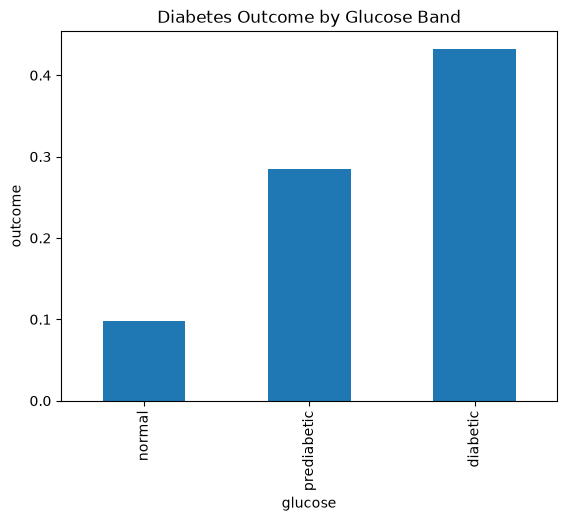

In [460]:
ax = pd.crosstab(df["glucose_category"],df["outcome"],normalize="index")[1].plot(kind = "bar")
ax.set_xlabel("glucose")
ax.set_ylabel("outcome")
ax.set_title("Diabetes Outcome by Glucose Band")

In [461]:
pd.crosstab(df['bmi_category'],df['outcome'],normalize='index')

outcome,0,1
bmi_category,,
under_weight,0.763158,0.236842
normal,0.750000,0.250000
over_weight,0.770213,0.229787
obese,0.676311,0.323689


# save your feature engineered dataset

In [462]:
df.to_csv(r"C:\Users\j\OneDrive\Desktop\5thsem_OJT\project1_diabates\data\processed\ashfiqua_P1W1_features.csv")